In [1]:
# 목적: 위기 국면에서 리스크 신호를 비선형적으로 증폭 (Copula 개념 도입)

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

data_path = os.path.expanduser("~/Desktop/SentriVaR-500/data")

# 저장된 데이터 로드
prices      = pd.read_csv(f"{data_path}/prices.csv", index_col="Date", parse_dates=True)
macro       = pd.read_csv(f"{data_path}/macro_daily.csv", index_col="DATE", parse_dates=True)
regime      = pd.read_csv(f"{data_path}/regime_states.csv", parse_dates=["date"])
risk_scores = pd.read_csv(f"{data_path}/final_risk_scores.csv", index_col="Date", parse_dates=True)

returns = prices.pct_change().dropna()
regime  = regime.set_index("date")

print("데이터 로드 완료")
print(f"  주가:        {prices.shape}")
print(f"  거시경제:    {macro.shape}")
print(f"  국면:        {regime.shape}")
print(f"  리스크점수:  {risk_scores.shape}")

데이터 로드 완료
  주가:        (2138, 5)
  거시경제:    (2123, 2)
  국면:        (2102, 2)
  리스크점수:  (2102, 5)


In [2]:
# Copula 개념 기반 비선형 리스크 증폭 함수
# 핵심 아이디어: 위기 국면일수록 개별 신호들이 서로를 증폭시킴
# 평상시: 신호들이 독립적으로 작동 (선형 합산)
# 위기시: 신호들이 상호작용하며 폭발적으로 증폭 (비선형)

def copula_risk_amplifier(risk_score, regime, vix, vix_mean=20.0):
    """
    국면과 VIX에 따라 리스크를 비선형적으로 증폭
    
    - Normal  (0): 선형 유지
    - Elevated(1): 중간 증폭
    - Crisis  (2): 폭발적 증폭 (꼬리 위험 반영)
    """
    if regime == 0:  # Normal
        return risk_score
    
    elif regime == 1:  # Elevated
        # VIX가 평균보다 높을수록 추가 증폭
        vix_factor = max(1.0, vix / vix_mean)
        return risk_score * (1 + 0.3 * (vix_factor - 1))
    
    else:  # Crisis
        # 꼬리 위험: 신호들이 서로를 폭발적으로 증폭
        # VIX가 높을수록 비선형 급등
        vix_factor = max(1.0, vix / vix_mean)
        tail_amplification = vix_factor ** 1.5  # 지수적 증폭
        return min(1.0, risk_score * tail_amplification)

# 전체 기간에 적용
combined = risk_scores.dropna()

combined["copula_risk_score"] = combined.apply(
    lambda row: copula_risk_amplifier(
        row["risk_score"],
        row["regime"],
        row["VIX"]
    ), axis=1
)

print("Copula 리스크 점수 계산 완료")
print(f"\n기존 리스크 점수 통계:")
print(combined["risk_score"].describe().round(4))
print(f"\nCopula 리스크 점수 통계:")
print(combined["copula_risk_score"].describe().round(4))


Copula 리스크 점수 계산 완료

기존 리스크 점수 통계:
count    2102.0000
mean        0.3092
std         0.0698
min         0.1851
25%         0.2650
50%         0.2920
75%         0.3661
max         0.9404
Name: risk_score, dtype: float64

Copula 리스크 점수 통계:
count    2102.0000
mean        0.3602
std         0.1507
min         0.1851
25%         0.2757
50%         0.3065
75%         0.3937
max         1.0000
Name: copula_risk_score, dtype: float64


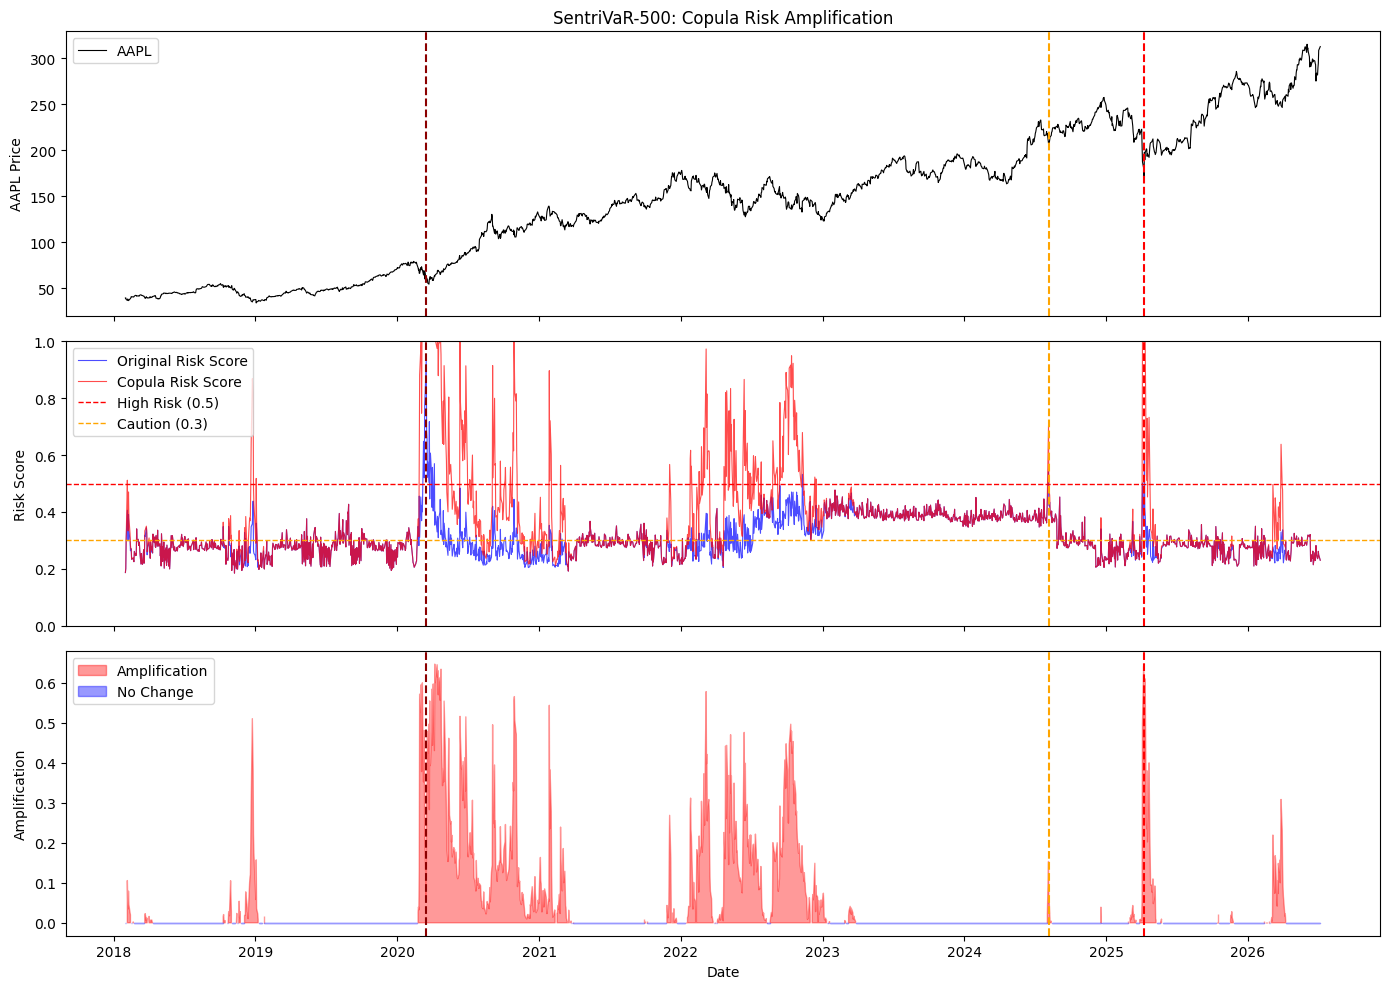

저장 완료: copula_risk.png


In [3]:
# 기존 vs Copula 리스크 점수 비교 시각화
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 주가
aapl = prices["AAPL"].reindex(combined.index)
ax1.plot(combined.index, aapl, color="black", linewidth=0.8, label="AAPL")
ax1.set_ylabel("AAPL Price")
ax1.set_title("SentriVaR-500: Copula Risk Amplification")
ax1.legend(loc="upper left")

# 기존 vs Copula 리스크 점수
ax2.plot(combined.index, combined["risk_score"],
         color="blue", linewidth=0.8, alpha=0.7, label="Original Risk Score")
ax2.plot(combined.index, combined["copula_risk_score"],
         color="red", linewidth=0.8, alpha=0.7, label="Copula Risk Score")
ax2.axhline(0.5, color="red", linestyle="--", linewidth=1, label="High Risk (0.5)")
ax2.axhline(0.3, color="orange", linestyle="--", linewidth=1, label="Caution (0.3)")
ax2.set_ylabel("Risk Score")
ax2.set_ylim(0, 1)
ax2.legend(loc="upper left")

# 차이 (Copula - Original)
diff = combined["copula_risk_score"] - combined["risk_score"]
ax3.fill_between(combined.index, 0, diff,
                 where=diff > 0, color="red", alpha=0.4, label="Amplification")
ax3.fill_between(combined.index, 0, diff,
                 where=diff <= 0, color="blue", alpha=0.4, label="No Change")
ax3.set_ylabel("Amplification")
ax3.set_xlabel("Date")
ax3.legend(loc="upper left")

# 케이스 스터디 이벤트
for ax in [ax1, ax2, ax3]:
    ax.axvline(pd.Timestamp("2020-03-16"), color="darkred",
               linestyle="--", linewidth=1.5)
    ax.axvline(pd.Timestamp("2024-08-05"), color="orange",
               linestyle="--", linewidth=1.5)
    ax.axvline(pd.Timestamp("2025-04-07"), color="red",
               linestyle="--", linewidth=1.5)

plt.tight_layout()
plt.savefig(f"{data_path}/copula_risk.png", dpi=150)
plt.show()
print("저장 완료: copula_risk.png")

In [4]:
# 최종 저장
combined[["regime", "regime_label", "VIX", "risk_score", "copula_risk_score"]].to_csv(
    f"{data_path}/copula_risk_scores.csv"
)
print("저장 완료: copula_risk_scores.csv")
print(f"\n현재 Copula 리스크 점수: {combined['copula_risk_score'].iloc[-1]:.4f}")
print(f"현재 Original 리스크 점수: {combined['risk_score'].iloc[-1]:.4f}")
print(f"현재 국면: {combined['regime_label'].iloc[-1]}")

print(combined.tail(3)[["VIX", "regime", "regime_label", "risk_score", "copula_risk_score"]])


저장 완료: copula_risk_scores.csv

현재 Copula 리스크 점수: 0.2304
현재 Original 리스크 점수: 0.2304
현재 국면: Elevated
              VIX  regime regime_label  risk_score  copula_risk_score
Date                                                                 
2026-07-01  16.59       1     Elevated      0.2617             0.2617
2026-07-02  16.15       1     Elevated      0.2493             0.2493
2026-07-06  15.57       1     Elevated      0.2304             0.2304


In [5]:
# 2020년 코로나 구간 확인
crisis_period = combined["2020-03-10":"2020-03-20"]
print(crisis_period[["VIX", "regime", "regime_label", "risk_score", "copula_risk_score"]])

              VIX  regime regime_label  risk_score  copula_risk_score
Date                                                                 
2020-03-10  47.30       2       Crisis      0.5501                1.0
2020-03-11  53.90       2       Crisis      0.5202                1.0
2020-03-12  75.47       2       Crisis      0.7769                1.0
2020-03-13  57.83       2       Crisis      0.8101                1.0
2020-03-16  82.69       2       Crisis      0.9404                1.0
2020-03-17  75.91       2       Crisis      0.6829                1.0
2020-03-18  76.45       2       Crisis      0.6608                1.0
2020-03-19  72.00       2       Crisis      0.5221                1.0
2020-03-20  66.04       2       Crisis      0.5763                1.0
